In [4]:
import pandas as pd
import numpy as np


In [6]:
df=pd.read_csv(r"C:\Users\medag\Downloads\jyothi.csv")
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",17-01-2025 18:00:00,26.071318,91.874880,PM10,75.0,252.0,177.0
1,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",17-01-2025 18:00:00,26.071318,91.874880,NH3,1.0,5.0,3.0
2,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",17-01-2025 18:00:00,26.071318,91.874880,OZONE,22.0,57.0,43.0
3,India,Assam,Guwahati,"IITG, Guwahati - PCBA",17-01-2025 18:00:00,26.202864,91.700464,PM10,59.0,199.0,152.0
4,India,Assam,Guwahati,"IITG, Guwahati - PCBA",17-01-2025 18:00:00,26.202864,91.700464,NH3,5.0,5.0,5.0


In [8]:
# Pivot to convert pollutants into columns
df_wide = df.pivot_table(index=['country', 'state', 'city', 'station', 'last_update'],
                         columns='pollutant_id',
                         values='pollutant_avg').reset_index()
df_wide = df_wide.fillna(df_wide.mean(numeric_only=True))


In [10]:
# Approximate AQI using PM10 (or PM2.5 if available)
df_wide['AQI'] = df_wide['PM10']

def classify_aqi(aqi):
    if pd.isna(aqi):
        return Unknown
    elif aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df_wide['AQI_Category'] = df_wide['AQI'].apply(classify_aqi)


In [12]:
# Fill missing values in original dataset
cols = ['pollutant_min', 'pollutant_max', 'pollutant_avg']
df[cols] = df[cols].fillna(df[cols].mean())

# After pivot
df_wide.fillna(df_wide.mean(numeric_only=True), inplace=True)


In [14]:
# Convert Strings to Datetime
df['last_update'] = pd.to_datetime(df['last_update'], dayfirst=True, errors='coerce')


In [16]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2025-01-17 18:00:00,26.071318,91.874880,PM10,75.0,252.0,177.0
1,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2025-01-17 18:00:00,26.071318,91.874880,NH3,1.0,5.0,3.0
2,India,Assam,Byrnihat,"Central Academy for SFS, Byrnihat - PCBA",2025-01-17 18:00:00,26.071318,91.874880,OZONE,22.0,57.0,43.0
3,India,Assam,Guwahati,"IITG, Guwahati - PCBA",2025-01-17 18:00:00,26.202864,91.700464,PM10,59.0,199.0,152.0
4,India,Assam,Guwahati,"IITG, Guwahati - PCBA",2025-01-17 18:00:00,26.202864,91.700464,NH3,5.0,5.0,5.0


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [20]:
# Drop rows with missing target values 
data_cleaned = df.dropna(subset=["pollutant_avg"]).copy()

In [22]:
# Categorize 'pollutant_avg' into classes (Low, Moderate, High)
# Using arbitrary thresholds for demonstration 
bins = [0, 50, 100, float('inf')]
labels = ["Low", "Moderate", "High"]
data_cleaned["pollutant_class"] = pd.cut(data_cleaned["pollutant_avg"], bins=bins, labels=labels)

In [24]:
# Encode categorical features
label_encoders = {}
categorical_columns = ["country", "state", "city", "station", "pollutant_id"]

for col in categorical_columns:
    le = LabelEncoder()
    data_cleaned[col] = le.fit_transform(data_cleaned[col])
    label_encoders[col] = le

In [26]:
# Drop unnecessary columns
data_preprocessed = data_cleaned.drop(columns=["last_update", "pollutant_min", "pollutant_max", "pollutant_avg"])

In [28]:
#split data into features(x) and target(y)


In [30]:
X = data_preprocessed.drop(columns=["pollutant_class"])
y = data_preprocessed["pollutant_class"]

In [32]:
from sklearn.preprocessing import LabelEncoder

X = df_wide[['PM10', 'NH3', 'OZONE']].fillna(df_wide[['PM10', 'NH3', 'OZONE']].mean())
le = LabelEncoder()
y = le.fit_transform(df_wide['AQI_Category'])


In [34]:
#split into training and testing set

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, pd.Series(y_train).value_counts(), pd.Series(y_test).value_counts()


((373, 3),
 (94, 3),
 1    307
 3     57
 2      5
 0      3
 4      1
 Name: count, dtype: int64,
 1    74
 3    13
 2     4
 0     3
 Name: count, dtype: int64)

In [ ]:
#KNN

In [51]:
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [53]:
knn_class=KNeighborsClassifier(n_neighbors=20, metric='minkowski', p=2 )
knn_class.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=20)

In [55]:
y_pred_knn=knn_class.predict(X_test)
Accuracy_Knn=round((metrics.accuracy_score(y_test, y_pred_knn)*100),2)
print('Accuracy (KNN): ',Accuracy_Knn,"%")

Accuracy (KNN):  89.36 %


In [67]:
#classification report

In [57]:

unique_classes = np.unique(np.concatenate((y_test, y_pred_knn)))

print(classification_report(
    y_test,
    y_pred_knn,
    target_names=[f'class {i}' for i in unique_classes],
    zero_division=0
))




              precision    recall  f1-score   support

     class 0       0.00      0.00      0.00         3
     class 1       0.83      0.86      0.84        22
     class 2       0.00      0.00      0.00         4
     class 3       0.81      1.00      0.90        13
     class 5       0.95      1.00      0.97        52

    accuracy                           0.89        94
   macro avg       0.52      0.57      0.54        94
weighted avg       0.83      0.89      0.86        94



In [83]:
#Decision Tree

In [69]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
DT_class=DecisionTreeClassifier(criterion='entropy', random_state=0)
DT_class.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [73]:
y_pred_DT= DT_class.predict(X_test)
Accuracy_DT=round((metrics.accuracy_score(y_test, y_pred_DT)*100),2)
print('Accuracy (Decision Tree): ',Accuracy_DT,"%")

Accuracy (Decision Tree):  100.0 %


In [91]:
#Classification Report


In [75]:
unique_classes = np.unique(np.concatenate((y_test, y_pred_svm)))

print(classification_report(y_test, y_pred_DT, target_names=[f'class {i}' for i in unique_classes]))

              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00         3
     class 1       1.00      1.00      1.00        22
     class 2       1.00      1.00      1.00         4
     class 3       1.00      1.00      1.00        13
     class 5       1.00      1.00      1.00        52

    accuracy                           1.00        94
   macro avg       1.00      1.00      1.00        94
weighted avg       1.00      1.00      1.00        94



In [95]:
#Random Forest

In [77]:
from sklearn.ensemble import RandomForestClassifier

In [79]:
random_class= RandomForestClassifier(n_estimators= 20, criterion="entropy")
random_class.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=20)

In [81]:
y_pred_RF= random_class.predict(X_test)
Accuracy_RF=round((metrics.accuracy_score(y_test, y_pred_RF)*100),2)
print('Accuracy (Random Forest): ',Accuracy_RF,"%")

Accuracy (Random Forest):  94.68 %


In [103]:
#Classification Report


In [83]:
unique_classes = np.unique(np.concatenate((y_test, y_pred_RF)))
print(classification_report(
    y_test,
    y_pred_RF,
    target_names=[f'class {i}' for i in unique_classes],
    zero_division=0
))


              precision    recall  f1-score   support

     class 0       1.00      1.00      1.00         3
     class 1       0.84      0.95      0.89        22
     class 2       0.00      0.00      0.00         4
     class 3       1.00      1.00      1.00        13
     class 5       0.98      1.00      0.99        52

    accuracy                           0.95        94
   macro avg       0.76      0.79      0.78        94
weighted avg       0.91      0.95      0.93        94



In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# Save model
joblib.dump(best_model, "aqi_rf_model.pkl")
joblib.dump(le, "label_encoder.pkl")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:776: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


['label_encoder.pkl']

In [ ]:
#Data Visualization

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Histogram


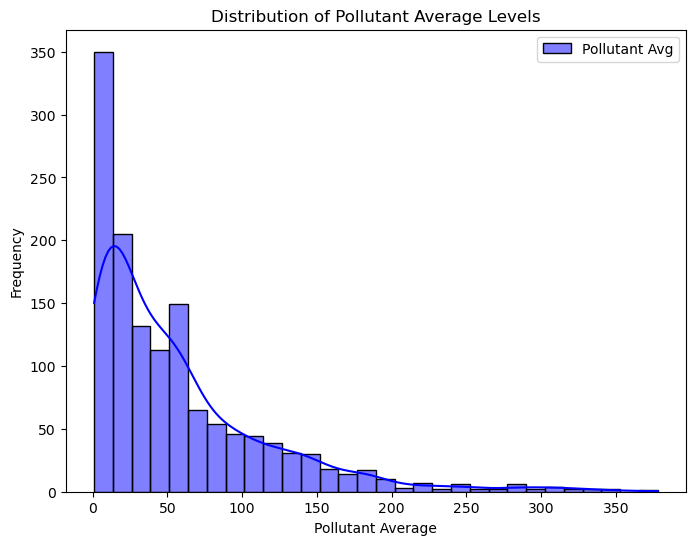

In [111]:
plt.figure(figsize=(8, 6))
sns.histplot(df1, x="pollutant_avg", kde=True, bins=30, color="blue", label="Pollutant Avg")
plt.title("Distribution of Pollutant Average Levels")
plt.xlabel("Pollutant Average")
plt.ylabel("Frequency")
plt.legend()  # now it has something to show
plt.show()


In [ ]:
#Heat Map


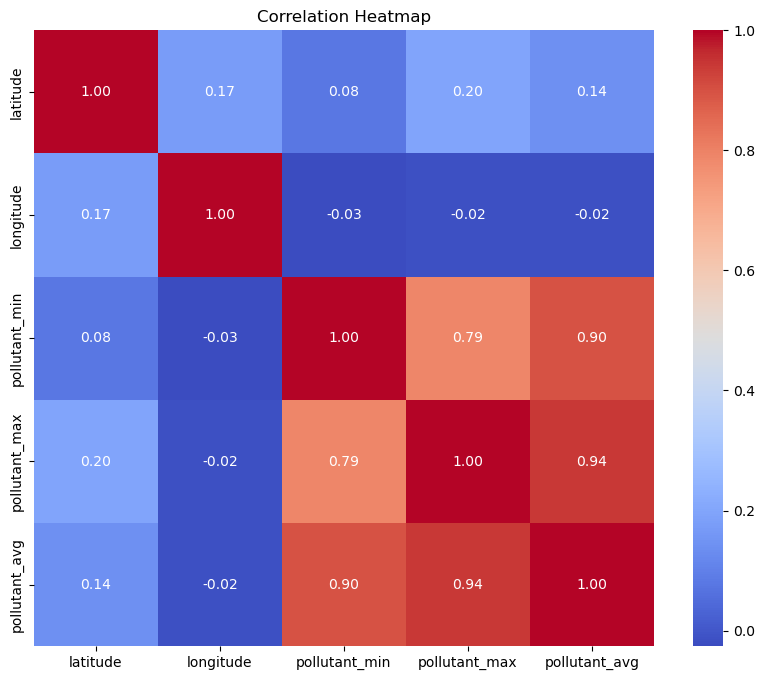

In [113]:
# Select only numeric columns for correlation
numeric_df = df1.select_dtypes(include='number')

# Now plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
#Count Plot

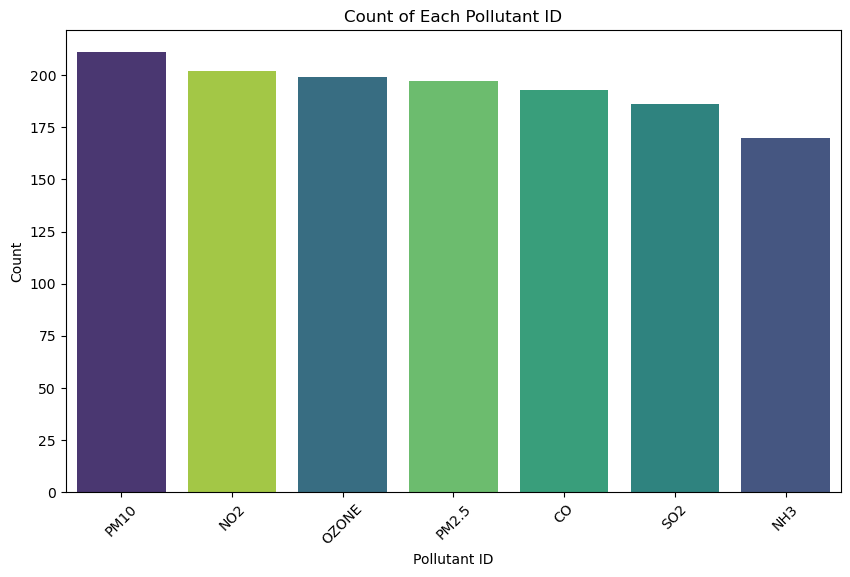

In [115]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df1, x="pollutant_id", hue="pollutant_id", 
              order=df1["pollutant_id"].value_counts().index, 
              palette="viridis", legend=False)
plt.title("Count of Each Pollutant ID")
plt.xlabel("Pollutant ID")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [46]:
import joblib

# Save the best trained model to a file
joblib.dump(best_model, "aqi_rf_model.pkl")
print("Model loaded successfully!")


Model loaded successfully!


In [48]:
import os
print(os.getcwd())

C:\Users\medag
